In [46]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

plt.style.use('bmh')

In [47]:
from constants import SENTENCE_CSV_PATH, RANDOM_STATE
NUM_LAYERS = 28
SAMPLE_SIZE = 70

In [48]:
# loading the sentence dataset
dataset = pd.read_csv("data/dataset.csv", index_col=0)
dataset['coll_freq_per_million'] = (dataset['coll_freq'] / dataset['obj_freq']) * 10**6
dataset = dataset.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset
dataset.reset_index(drop=True, inplace=True)

In [49]:
dataset['noun_eng'].unique()

array(['apple', 'ball', 'woman', 'dress', 'man', 'milk', 'president',
       'game'], dtype=object)

In [50]:
dataset_index_subj_i = dataset[dataset.sentence_eng.str.startswith('I')].index
dataset_index_subj_h = dataset[dataset.sentence_eng.str.startswith('He')].index
dataset_index_subj_m = dataset[dataset.sentence_eng.str.startswith('The man')].index
dataset_index_subj_w = dataset[dataset.sentence_eng.str.startswith('The woman')].index

dataset_index_apple = dataset[dataset.noun_eng == 'apple'].index
dataset_index_milk = dataset[dataset.noun_eng == 'milk'].index
dataset_index_ball = dataset[dataset.noun_eng == 'ball'].index
dataset_index_dress = dataset[dataset.noun_eng == 'dress'].index
dataset_index_game = dataset[dataset.noun_eng == 'game'].index
dataset_index_president = dataset[dataset.noun_eng == 'president'].index
dataset_index_man = dataset[dataset.noun_eng == 'man'].index
dataset_index_woman = dataset[dataset.noun_eng == 'woman'].index

Creating matrices of layer prediction indicators, so that it would be easier to plot them:

In [52]:
layer_arrays = defaultdict(lambda: np.zeros((len(dataset), NUM_LAYERS)))

for l in range(NUM_LAYERS):
    layer_arrays[f'perf_eng_top3'][:, l] = dataset[f'layer_{l}_perf_eng_top3'].to_numpy(dtype=np.int64)
    layer_arrays[f'past_eng_top3'][:, l] = dataset[f'layer_{l}_past_eng_top3'].to_numpy(dtype=np.int64) 
    layer_arrays[f'perf_ger_top3'][:, l] = dataset[f'layer_{l}_perf_ger_top3'].to_numpy(dtype=np.int64)
    layer_arrays[f'noun_eng_top3'][:, l] = dataset[f'layer_{l}_noun_eng_top3'].to_numpy(dtype=np.int64)
    layer_arrays[f'noun_ger_top3'][:, l] = dataset[f'layer_{l}_noun_ger_top3'].to_numpy(dtype=np.int64)


Apart from the indicators we do have, it would be sensible to have one for predicting a past form of the English verb as well:

In [53]:
layer_arrays['verb_eng_top3'] = ((layer_arrays[f'perf_eng_top3'] == 1) | (layer_arrays[f'past_eng_top3'] == 1)).astype(np.int64)

## Top-3

### Different word predictions by layer

#### English noun

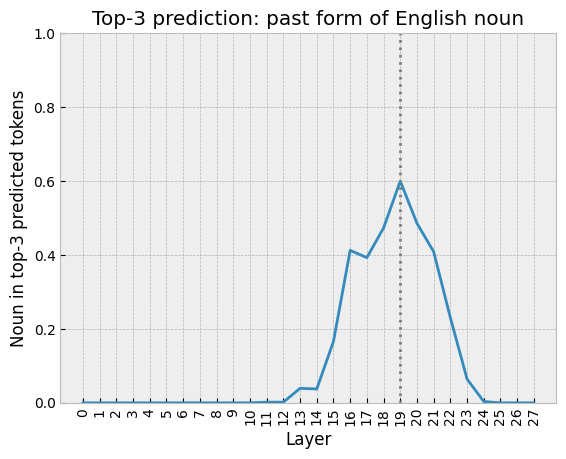

In [54]:
plt.plot(layer_arrays['noun_eng_top3'].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.axvline(x=19, color='gray', linestyle=":")
plt.title("Top-3 prediction: past form of English noun")
plt.xlabel("Layer")
plt.ylabel("Noun in top-3 predicted tokens")
plt.show()

##### by object

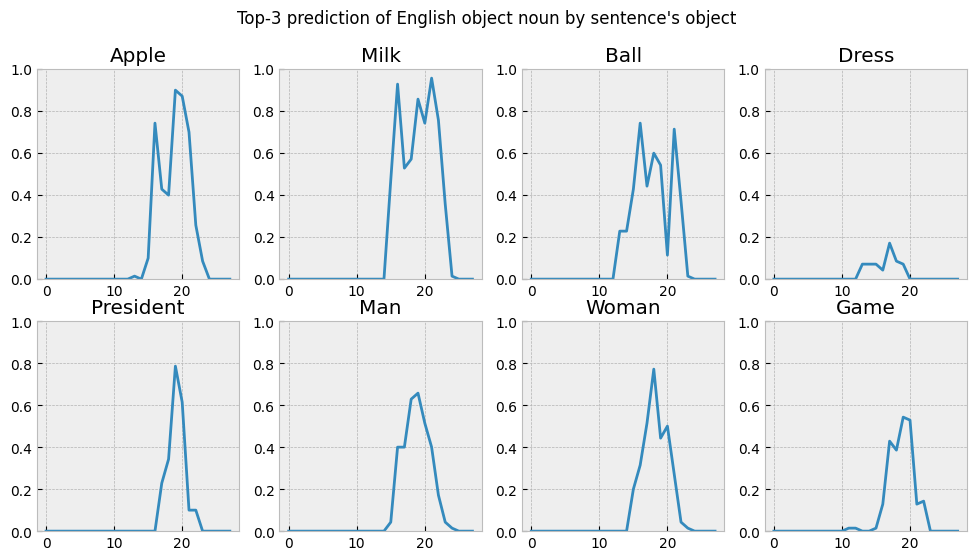

In [55]:
figure = plt.figure(figsize=(12,6))
figure.suptitle("Top-3 prediction of English object noun by sentence's object")

axis = figure.subplots(2, 4)

axis[0, 0].plot(layer_arrays['noun_eng_top3'][dataset_index_apple].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].set_title("Apple")

axis[0, 1].plot(layer_arrays['noun_eng_top3'][dataset_index_milk].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].set_title("Milk")

axis[0, 2].plot(layer_arrays['noun_eng_top3'][dataset_index_ball].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].set_title("Ball")

axis[0, 3].plot(layer_arrays['noun_eng_top3'][dataset_index_dress].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].set_title("Dress")

axis[1, 0].plot(layer_arrays['noun_eng_top3'][dataset_index_president].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].set_title("President")

axis[1, 1].plot(layer_arrays['noun_eng_top3'][dataset_index_man].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].set_title("Man")

axis[1, 2].plot(layer_arrays['noun_eng_top3'][dataset_index_woman].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].set_title("Woman")

axis[1, 3].plot(layer_arrays['noun_eng_top3'][dataset_index_game].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].set_title("Game")

plt.show()

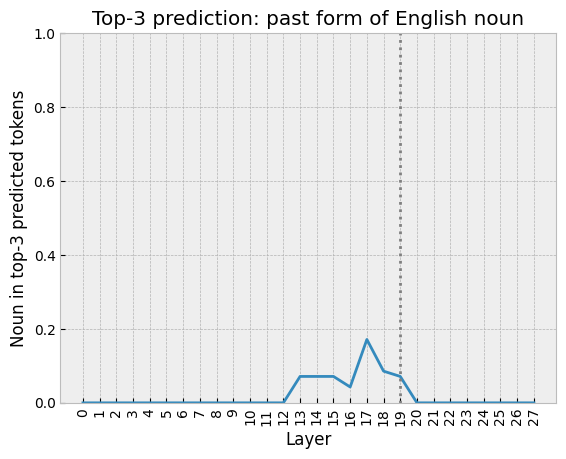

In [56]:
# more detailed plot of dress
plt.plot(layer_arrays['noun_eng_top3'][dataset_index_dress].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.axvline(x=19, color='gray', linestyle=":")
plt.title("Top-3 prediction: past form of English noun")
plt.xlabel("Layer")
plt.ylabel("Noun in top-3 predicted tokens")
plt.show()

##### Dress

In [57]:
dataset[dataset.noun_eng == 'dress'].layer_19_pred_0.value_counts()

Ġdie           30
Ġthe           14
Ġchoice         8
te              5
Ġfound          2
Ġdiscovered     2
Ġchanged        2
Ġopen           2
Ġshown          1
Ġpresented      1
Ġgift           1
Ġmit            1
Ġmissed         1
Name: layer_19_pred_0, dtype: int64

In [58]:
dataset[dataset.noun_eng == 'game'].layer_19_pred_0.value_counts()

Ġgame             20
Ġdie              12
Ġcreated           3
Ġrecommended       3
Ġunderstanding     3
Ġstart             3
Ġmissed            2
Ġled               2
Ġcontrol           2
Ġgames             2
Ġimproved          2
Ġbegin             2
Ġprepared          2
Ġplayed            1
Ġinterrupted       1
Ġwin               1
Ġexpected          1
Ġpresented         1
te                 1
Ġpublished         1
Ġthe               1
Ġwatched           1
Ġenjoyed           1
Ġoffer             1
Ġbroadcast         1
Name: layer_19_pred_0, dtype: int64

##### by subject

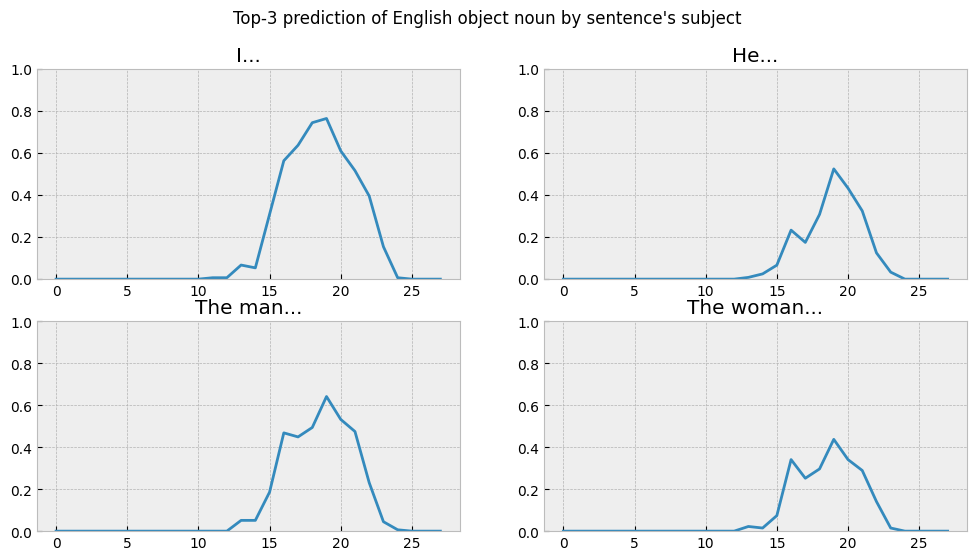

In [59]:
figure = plt.figure(figsize=(12,6))
figure.suptitle("Top-3 prediction of English object noun by sentence's subject")

axis = figure.subplots(2, 2)

axis[0, 0].plot(layer_arrays['noun_eng_top3'][dataset_index_subj_i].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].set_title("I...")

axis[0, 1].plot(layer_arrays['noun_eng_top3'][dataset_index_subj_h].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].set_title("He...")

axis[1, 0].plot(layer_arrays['noun_eng_top3'][dataset_index_subj_m].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].set_title("The man...")

axis[1, 1].plot(layer_arrays['noun_eng_top3'][dataset_index_subj_w].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].set_title("The woman...")

plt.show()

#### English verb

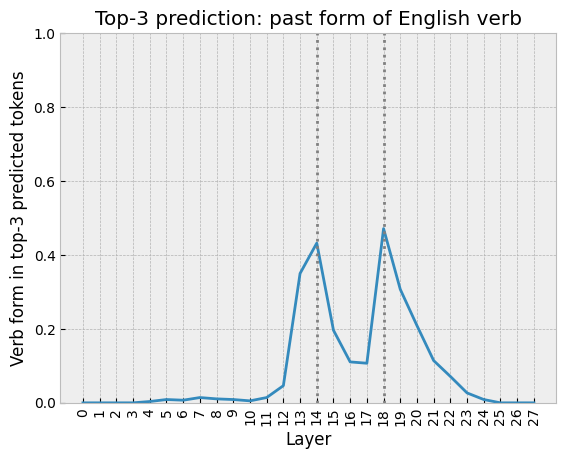

In [60]:
plt.plot(layer_arrays['verb_eng_top3'].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.axvline(x=14, color='gray', linestyle=":")
plt.axvline(x=18, color='gray', linestyle=":")
plt.title("Top-3 prediction: past form of English verb")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")

plt.savefig('results/figures/verb_eng_top3.png', dpi=300)
plt.show()

##### by object

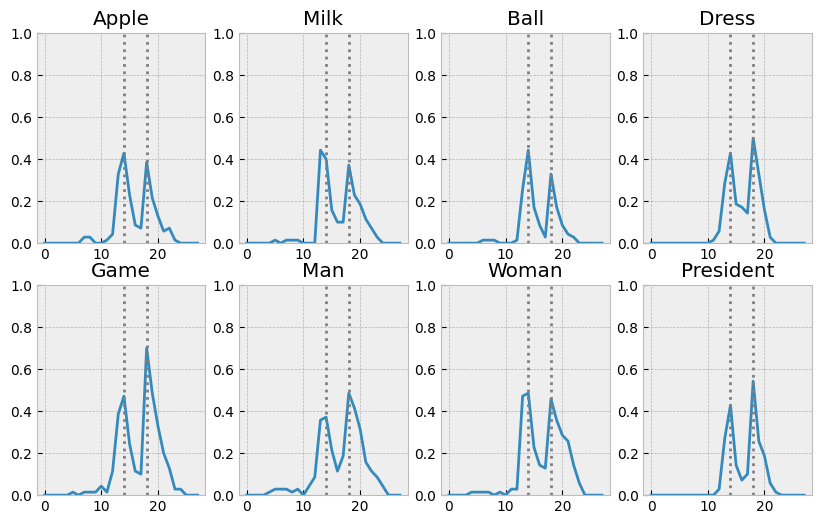

In [61]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 4)

axis[0, 0].plot(layer_arrays['verb_eng_top3'][dataset_index_apple].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].axvline(x=14, color='gray', linestyle=":")
axis[0, 0].axvline(x=18, color='gray', linestyle=":")
axis[0, 0].set_title("Apple")

axis[0, 1].plot(layer_arrays['verb_eng_top3'][dataset_index_milk].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=14, color='gray', linestyle=":")
axis[0, 1].axvline(x=18, color='gray', linestyle=":")
axis[0, 1].set_title("Milk")

axis[0, 2].plot(layer_arrays['verb_eng_top3'][dataset_index_ball].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].axvline(x=14, color='gray', linestyle=":")
axis[0, 2].axvline(x=18, color='gray', linestyle=":")
axis[0, 2].set_title("Ball")

axis[0, 3].plot(layer_arrays['verb_eng_top3'][dataset_index_dress].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].axvline(x=14, color='gray', linestyle=":")
axis[0, 3].axvline(x=18, color='gray', linestyle=":")
axis[0, 3].set_title("Dress")

axis[1, 0].plot(layer_arrays['verb_eng_top3'][dataset_index_game].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=14, color='gray', linestyle=":")
axis[1, 0].axvline(x=18, color='gray', linestyle=":")
axis[1, 0].set_title("Game")

axis[1, 1].plot(layer_arrays['verb_eng_top3'][dataset_index_man].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].axvline(x=14, color='gray', linestyle=":")
axis[1, 1].axvline(x=18, color='gray', linestyle=":")
axis[1, 1].set_title("Man")

axis[1, 2].plot(layer_arrays['verb_eng_top3'][dataset_index_woman].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].axvline(x=14, color='gray', linestyle=":")
axis[1, 2].axvline(x=18, color='gray', linestyle=":")
axis[1, 2].set_title("Woman")

axis[1, 3].plot(layer_arrays['verb_eng_top3'][dataset_index_president].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].axvline(x=14, color='gray', linestyle=":")
axis[1, 3].axvline(x=18, color='gray', linestyle=":")
axis[1, 3].set_title("President")

plt.savefig('results/figures/verb_eng_top3_by_obj.png', dpi=300)
plt.show()

##### by subject

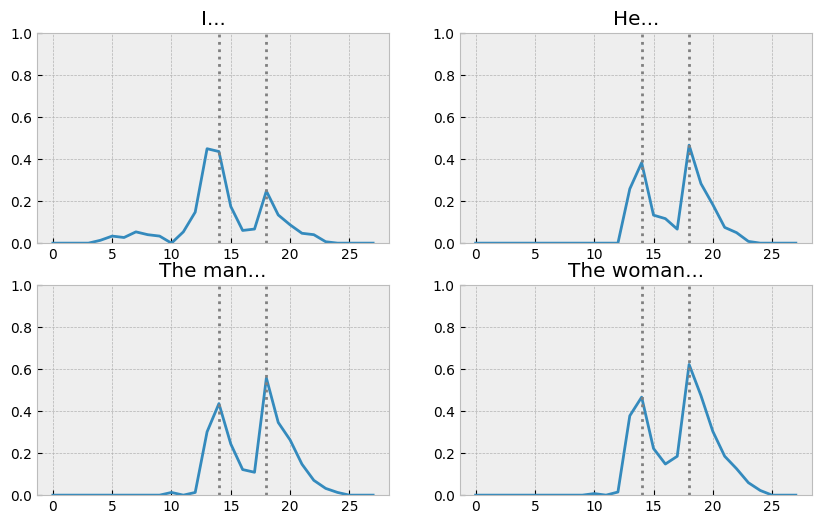

In [62]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 2)

axis[0, 0].plot(layer_arrays['verb_eng_top3'][dataset_index_subj_i].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].axvline(x=14, color='gray', linestyle=":")
axis[0, 0].axvline(x=18, color='gray', linestyle=":")
axis[0, 0].set_title("I...")

axis[0, 1].plot(layer_arrays['verb_eng_top3'][dataset_index_subj_h].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=14, color='gray', linestyle=":")
axis[0, 1].axvline(x=18, color='gray', linestyle=":")
axis[0, 1].set_title("He...")

axis[1, 0].plot(layer_arrays['verb_eng_top3'][dataset_index_subj_m].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=14, color='gray', linestyle=":")
axis[1, 0].axvline(x=18, color='gray', linestyle=":")
axis[1, 0].set_title("The man...")

axis[1, 1].plot(layer_arrays['verb_eng_top3'][dataset_index_subj_w].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].axvline(x=14, color='gray', linestyle=":")
axis[1, 1].axvline(x=18, color='gray', linestyle=":")
axis[1, 1].set_title("The woman...")

plt.show()

##### Qualitative analysis

In [78]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_ger').mean()['coll_freq_per_million']

noun_ger
Apfel         638.644661
Ball         1375.153776
Frau          611.551452
Kleid        1572.023120
Mann          489.307410
Milch         899.307150
Präsident     268.419250
Spiel         949.706879
Name: coll_freq_per_million, dtype: float64

In [73]:
print(
pd.concat(
    [dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_ger').mean()['coll_freq_per_million'],
    dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].groupby('noun_ger').mean()['coll_freq_per_million']],
    axis=1
).to_latex()
)

\begin{tabular}{lrr}
\toprule
{} &  coll\_freq\_per\_million &  coll\_freq\_per\_million \\
noun\_ger  &                        &                        \\
\midrule
Apfel     &             638.644661 &            1361.053222 \\
Ball      &            1375.153776 &            2941.909227 \\
Frau      &             611.551452 &             420.426411 \\
Kleid     &            1572.023120 &            1497.976093 \\
Mann      &             489.307410 &             447.044499 \\
Milch     &             899.307150 &            1811.428465 \\
Präsident &             268.419250 &             229.406650 \\
Spiel     &             949.706879 &            1642.634089 \\
\bottomrule
\end{tabular}



In [34]:
print(
    dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_ger').mean()['coll_freq_per_million'].to_latex()
)

\begin{tabular}{lr}
\toprule
{} &  coll\_freq\_per\_million \\
noun\_ger  &                        \\
\midrule
Apfel     &             564.620820 \\
Ball      &            1310.006548 \\
Frau      &             499.284966 \\
Kleid     &            1216.023490 \\
Mann      &             636.451325 \\
Milch     &             986.773279 \\
Präsident &             191.739853 \\
Spiel     &            1534.692311 \\
\bottomrule
\end{tabular}



In [64]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].mean()['coll_freq_per_million']

/Users/fixed/Desktop/saar/word_order_logitlens/envs/word-order/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


834.1530484472901

In [83]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].perf_eng.unique()

array(['added', 'painted', 'shown', 'recognised', 'cut', 'shared',
       'replaced', 'seen', 'discovered', 'offered', 'received', 'enjoyed',
       'chosen', 'found', 'washed', 'named', 'stopped', 'controlled',
       'rolled', 'provided', 'touched', 'intercepted', 'reached', 'asked',
       'sent', 'visited', 'taken', 'watched', 'married', 'raped', 'known',
       'heard', 'killed', 'bought', 'brought', 'portrayed', 'held',
       'ordered', 'presented', 'opened', 'tailored', 'changed',
       'required', 'missed', 'saved', 'called', 'noticed', 'judged',
       'labelled', 'expected', 'reminded', 'arrested', 'sold', 'refused',
       'drawn', 'prepared', 'produced', 'delivered', 'tolerated',
       'needed', 'milked', 'transformed', 'recommended', 'appointed',
       'removed', 'protected', 'empowered', 'invited', 'met',
       'represented', 'elected', 'convinced', 'demonstrated',
       'designated', 'defended', 'honoured', 'insulted', 'transferred',
       'instructed', 'requested

In [79]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_eng').layer_18_noun_eng_top3.mean()

noun_eng
apple        0.222222
ball         0.304348
dress        0.000000
game         0.224490
man          0.323529
milk         0.269231
president    0.078947
woman        0.531250
Name: layer_18_noun_eng_top3, dtype: float64

In [33]:
print(
    dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_eng').layer_18_noun_eng_top3.mean().to_latex()
)

\begin{tabular}{lr}
\toprule
{} &  layer\_18\_noun\_eng\_top3 \\
noun\_eng  &                         \\
\midrule
apple     &                0.147059 \\
ball      &                0.346154 \\
dress     &                0.000000 \\
game      &                0.304348 \\
man       &                0.382979 \\
milk      &                0.266667 \\
president &                0.101695 \\
woman     &                0.565217 \\
\bottomrule
\end{tabular}



In [28]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].groupby('noun_ger').mean()['coll_freq_per_million']

noun_ger
Apfel        1289.031923
Ball         2683.921280
Frau          489.371776
Kleid        1774.847129
Mann          523.025918
Milch        2462.921369
Präsident     232.658204
Spiel        1083.017114
Name: coll_freq_per_million, dtype: float64

In [29]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].mean()['coll_freq_per_million']

/Users/fixed/Desktop/saar/word_order_logitlens/envs/word-order/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


1424.6078013394083

In [82]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].perf_eng.unique()

array(['grated', 'discovered', 'held', 'turned', 'replaced', 'halved',
       'consumed', 'diced', 'pressed', 'cored', 'stolen', 'recognised',
       'eaten', 'painted', 'gifted', 'brought', 'rubbed', 'washed',
       'peeled', 'quartered', 'taken', 'found', 'conquered', 'reached',
       'stopped', 'received', 'intercepted', 'touched', 'kicked',
       'secured', 'won', 'parried', 'rolled', 'provided', 'raped',
       'killed', 'bought', 'seen', 'left', 'saved', 'portrayed', 'freed',
       'hit', 'known', 'named', 'murdered', 'lost', 'got', 'worn', 'cut',
       'ordered', 'thrown', 'shown', 'manufactured', 'packed', 'sewn',
       'wrapped', 'tailored', 'set', 'kept', 'opened', 'required',
       'visited', 'kissed', 'seduced', 'met', 'shot', 'seated', 'hurt',
       'labelled', 'mixed', 'used', 'drunk', 'whisked', 'fed',
       'transformed', 'spilled', 'given', 'poured', 'sucked', 'squirted',
       'frothed', 'dispensed', 'helped', 'drawn', 'utilised', 'tilted',
       'stirred',

In [25]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].groupby('noun_eng').layer_18_noun_eng_top3.mean()

noun_eng
apple        0.541667
ball         0.768116
dress        0.195122
game         0.795918
man          0.916667
milk         0.657303
president    0.634921
woman        0.967213
Name: layer_18_noun_eng_top3, dtype: float64

In [31]:
dataset[dataset_index_woman][(layer_arrays['verb_eng_top3'][:, 18] == 0)].layer_18_preds

AttributeError: 'Int64Index' object has no attribute 'index'

#### English Past Pariciple vs. Past

For those sentences, where the predicate is a verb with two different forms, such as *ate*/*eaten* or *took*/*taken*:

In [173]:
different_verbforms = dataset[dataset.perf_eng != dataset.past_eng]
different_verbforms.tail()

,sentence_ger,sentence_eng,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,noun_ger,noun_eng,...,layer_19_pred_2,layer_20_pred_2,layer_21_pred_2,layer_22_pred_2,layer_23_pred_2,layer_24_pred_2,layer_25_pred_2,layer_26_pred_2,layer_27_pred_2,coll_relative_freq
698,Er hat das Spiel begonnen,He began the game,10304,7.48,5774929,begonnen,begun,began,Spiel,game,...,Ġstart,Ġbegin,Ġbegan,Ġstart,Ġden,Ġden,Ġdie,te,te,0.001784
707,Der Mann hat das Spiel gesehen,The man saw the game,20910,7.00,5774929,gesehen,seen,saw,Spiel,game,...,Ġdie,Ġgame,Ġmit,Ġdies,Ġdies,Ġden,Ġdie,Ġdie,Ġdie,0.003621
727,Ich habe das Spiel geholt,I took the game,2533,5.40,5774929,geholt,taken,took,Spiel,game,...,Ġdie,Ġgames,Ġden,Ġdies,Ġdies,Ġden,Ġden,Ġdie,Ġdie,0.000439
748,Der Mann hat das Spiel genommen,The man took the game,7006,5.10,5774929,genommen,taken,took,Spiel,game,...,Ġthe,Ġthe,Ġden,te,Ġdies,Ġd,Ġden,Ġdie,Ġdie,0.001213
757,Er hat das Spiel gezeigt,He showed the game,10813,6.41,5774929,gezeigt,shown,showed,Spiel,game,...,Ġdie,Ġgame,Ġden,te,Ġdies,Ġdies,Ġdie,te,Ġdie,0.001872


What are the predictions of the past participle verb forms compared past simple?

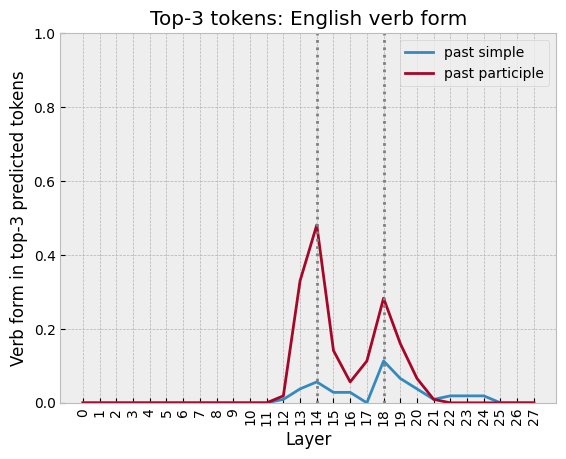

In [174]:
past_forms = layer_arrays['past_eng_top3'][different_verbforms.index].mean(axis=0)
perf_forms = layer_arrays['perf_eng_top3'][different_verbforms.index].mean(axis=0)

plt.plot(past_forms, label="past simple")
plt.plot(perf_forms, label="past participle")
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.axvline(x=14, color='gray', linestyle=":")
plt.axvline(x=18, color='gray', linestyle=":")
plt.title("Top-3 tokens: English verb form")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")
plt.legend()
plt.savefig("results/figures/past_vs_perf_eng.png", dpi=300)
plt.show()

#### English Noun vs. English Verb

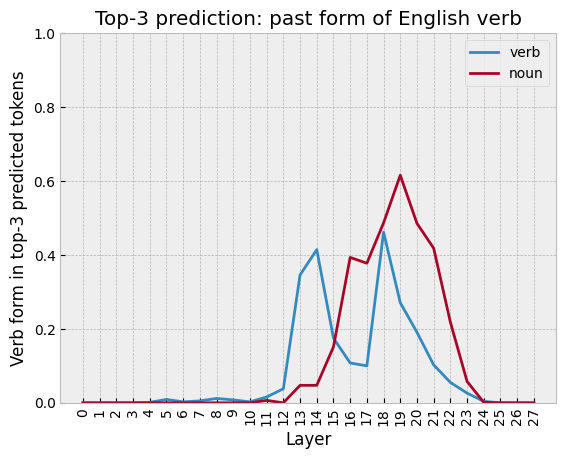

In [210]:
plt.plot(layer_arrays['verb_eng_top3'].mean(axis=0), label="verb")
plt.plot(layer_arrays['noun_eng_top3'].mean(axis=0), label="noun")
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.title("Top-3 prediction: past form of English verb")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")
plt.legend()

# plt.savefig('results/figures/verb_eng_top3.png', dpi=300)
plt.show()

#### logDice

In [280]:
logdice_bin = pd.Series(pd.cut(logdice, 10))

In [281]:
dataset['logdice_bin'] = logdice_bin.values

In [283]:
dataset.head()

,sentence_ger,sentence_eng,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,noun_ger,noun_eng,...,layer_20_pred_2,layer_21_pred_2,layer_22_pred_2,layer_23_pred_2,layer_24_pred_2,layer_25_pred_2,layer_26_pred_2,layer_27_pred_2,coll_relative_freq,logdice_bin
0,Die Frau hat den Apfel geschnitten,The woman cut the apple,1212,6.73,314787,geschnitten,cut,cut,Apfel,apple,...,Ġdie,Ġden,Ġmit,Ġmit,Ġd,Ġden,Ġdie,Ġdie,0.003850,"(5.924, 6.883]"
1,Die Frau hat den Apfel gestohlen,The woman stole the apple,187,5.57,314787,gestohlen,stolen,stole,Apfel,apple,...,ĠApple,Ġden,te,Ġdies,Ġd,Ġden,Ġd,Ġdie,0.000594,"(4.965, 5.924]"
2,Ich habe den Apfel verzehrt,I consumed the apple,92,5.38,314787,verzehrt,consumed,consumed,Apfel,apple,...,ĠApple,Ġapples,Ġapple,Ġd,Ġd,Ġden,Ġdie,Ġdie,0.000292,"(4.965, 5.924]"
3,Er hat den Apfel gezeigt,He showed the apple,135,0.49,314787,gezeigt,shown,showed,Apfel,apple,...,Ġshown,Ġden,te,te,te,te,Ġd,Ġdie,0.000429,"(0.16, 1.129]"
4,Die Frau hat den Apfel geraspelt,The woman grated the apple,157,6.74,314787,geraspelt,grated,grated,Apfel,apple,...,te,Ġapple,te,te,Ġd,Ġden,Ġdie,te,0.000499,"(5.924, 6.883]"


In [318]:
[interval.left for interval in dataset.groupby('logdice_bin')['layer_18_past_eng_top3'].mean().keys()]

[0.16, 1.129, 2.088, 3.047, 4.006, 4.965, 5.924, 6.883, 7.842, 8.801]

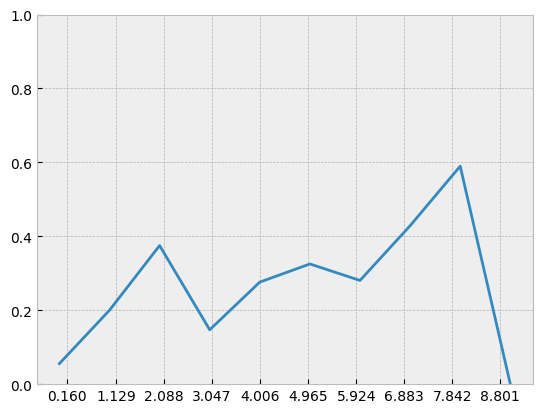

In [329]:
plt.plot(dataset.groupby('logdice_bin')['layer_13_past_eng_top3'].mean().values)
plt.ylim([0,1])
plt.xticks([interval.left for interval in dataset.groupby('logdice_bin')['layer_18_past_eng_top3'].mean().keys()])
plt.show()